<a href="https://colab.research.google.com/github/cynthiazhang98/COMSW4995-cynthiazhang98-A3/blob/main/4995A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup

In [20]:
!pip install tokenizers

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import requests
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

torch.manual_seed(42)
np.random.seed(42)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


###Loading data

In [22]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text
print(f"Total characters: {len(text)}")
print(text[:500])

Total characters: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [24]:
non_ascii = [(i, c) for i, c in enumerate(text) if ord(c) > 127]
print(f"Non-ASCII characters found: {len(non_ascii)}")

Non-ASCII characters found: 0


In [5]:
split_idx = int(0.8 * len(text))
train_text = text[:split_idx]
val_text   = text[split_idx:]

print(f"Train chars: {len(train_text)}, Val chars: {len(val_text)}")

Train chars: 892315, Val chars: 223079


###Tokenize with BPE

In [7]:
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=500, special_tokens=["[UNK]"])

tokenizer.train_from_iterator([train_text], trainer=trainer)

train_ids = tokenizer.encode(train_text).ids
val_ids   = tokenizer.encode(val_text).ids

print(f"Train tokens: {len(train_ids)}, Val tokens: {len(val_ids)}")
print(f"Vocab size: {tokenizer.get_vocab_size()}")

Train tokens: 356261, Val tokens: 92599
Vocab size: 500


token freq bar chart

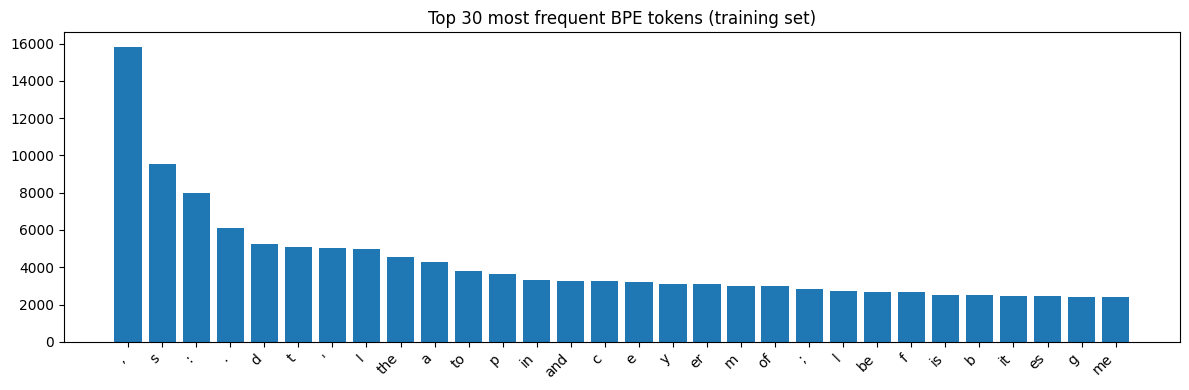

In [8]:
from collections import Counter

counts = Counter(train_ids)
top_tokens = counts.most_common(30)
labels = [tokenizer.id_to_token(t[0]) for t in top_tokens]
values = [t[1] for t in top_tokens]

plt.figure(figsize=(12, 4))
plt.bar(labels, values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 30 most frequent BPE tokens (training set)")
plt.tight_layout()
plt.savefig("token_freq.png", dpi=150)
plt.show()

Build Dataset

In [10]:
SEQ_LEN = 50

class ShakespeareDataset(Dataset):
    def __init__(self, token_ids, seq_len):
        self.data = torch.tensor(token_ids, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

train_dataset = ShakespeareDataset(train_ids, SEQ_LEN)
val_dataset   = ShakespeareDataset(val_ids,   SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 5566, Val batches: 1447


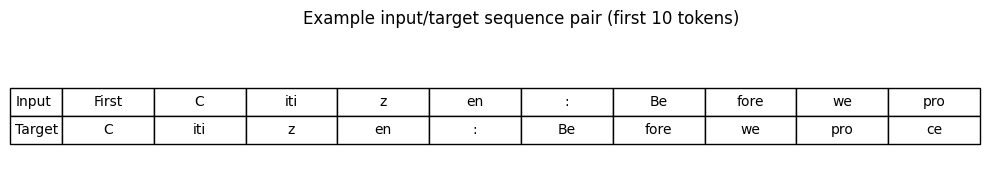

In [26]:
sample_x, sample_y = train_dataset[0]

input_tokens  = [tokenizer.id_to_token(i.item()) for i in sample_x[:10]]
target_tokens = [tokenizer.id_to_token(i.item()) for i in sample_y[:10]]

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')
table = ax.table(
    cellText=[input_tokens, target_tokens],
    rowLabels=['Input', 'Target'],
    loc='center',
    cellLoc='center'
)
table.scale(1, 2)
table.auto_set_font_size(False)
table.set_fontsize(10)
plt.title("Example input/target sequence pair (first 10 tokens)", pad=20)
plt.tight_layout()
plt.savefig("input_target_table.png", dpi=150, bbox_inches='tight')
plt.show()

###Building The Model

Positional Encoding

In [11]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

RMSNorm

In [12]:
class RMSNorm(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        rms = x.norm(dim=-1, keepdim=True) / math.sqrt(x.shape[-1])
        return self.scale * x / (rms + 1e-8)

Causal self-attention

In [13]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        weights = torch.softmax(scores, dim=-1)
        out = (weights @ v).transpose(1, 2).reshape(B, T, C)
        return self.out_proj(out), weights.detach()

Transformer Block

In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn  = CausalSelfAttention(d_model, n_heads)
        self.norm2 = RMSNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )

    def forward(self, x):
        attn_out, weights = self.attn(self.norm1(x))
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x, weights

Transformer full Model

In [15]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=2, max_len=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_len)
        self.blocks    = nn.ModuleList([TransformerBlock(d_model, n_heads) for _ in range(n_layers)])
        self.norm      = RMSNorm(d_model)
        self.lm_head   = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.pos_enc(self.embedding(x))
        all_weights = []
        for block in self.blocks:
            x, w = block(x)
            all_weights.append(w)
        x = self.norm(x)
        logits = self.lm_head(x)
        return logits, all_weights

VOCAB_SIZE = tokenizer.get_vocab_size()
model = TinyTransformer(vocab_size=VOCAB_SIZE).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 524,660


###Train

In [16]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS = 10
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
            total_val_loss += loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val   = total_val_loss   / len(val_loader)
    ppl       = math.exp(avg_val)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train loss: {avg_train:.4f} | Val loss: {avg_val:.4f} | PPL: {ppl:.2f}")

Epoch 1/10 | Train loss: 3.4930 | Val loss: 4.0104 | PPL: 55.17
Epoch 2/10 | Train loss: 2.7965 | Val loss: 4.2921 | PPL: 73.12
Epoch 3/10 | Train loss: 2.5220 | Val loss: 4.5889 | PPL: 98.39
Epoch 4/10 | Train loss: 2.3442 | Val loss: 4.8974 | PPL: 133.94
Epoch 5/10 | Train loss: 2.2166 | Val loss: 5.1311 | PPL: 169.21
Epoch 6/10 | Train loss: 2.1200 | Val loss: 5.3972 | PPL: 220.79
Epoch 7/10 | Train loss: 2.0440 | Val loss: 5.5842 | PPL: 266.19
Epoch 8/10 | Train loss: 1.9823 | Val loss: 5.7956 | PPL: 328.83
Epoch 9/10 | Train loss: 1.9314 | Val loss: 5.9856 | PPL: 397.65
Epoch 10/10 | Train loss: 1.8886 | Val loss: 6.1318 | PPL: 460.27


Loss Curve

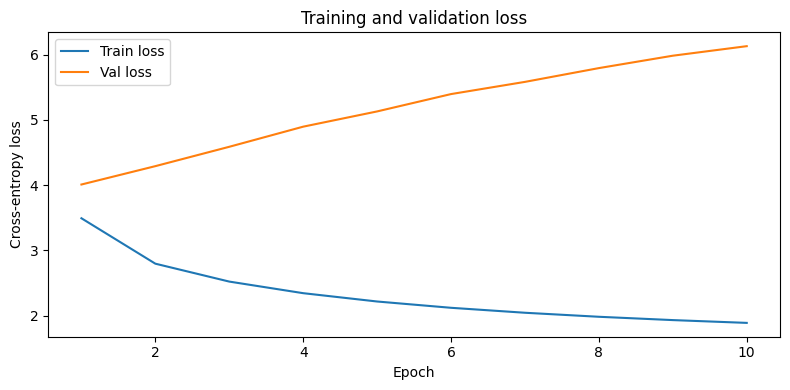

Final validation perplexity: 460.27


In [17]:
epochs = range(1, EPOCHS + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and validation loss")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

final_ppl = math.exp(val_losses[-1])
print(f"Final validation perplexity: {final_ppl:.2f}")

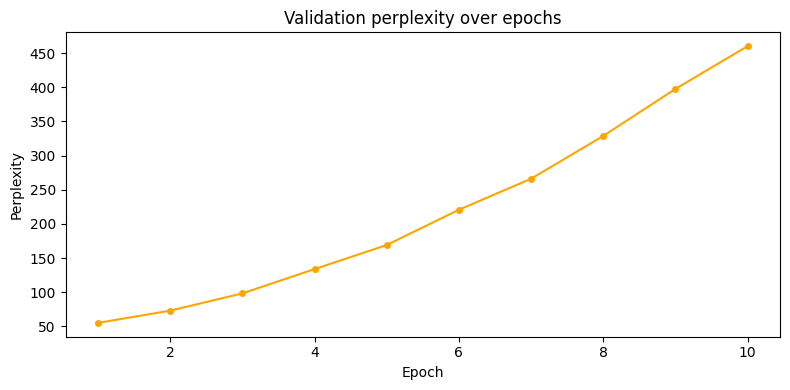

Best PPL: 55.17 at epoch 1
Final PPL: 460.27


In [29]:
ppls = [math.exp(v) for v in val_losses]

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), ppls, color='orange', marker='o', markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Validation perplexity over epochs")
plt.tight_layout()
plt.savefig("perplexity_curve.png", dpi=150)
plt.show()

print(f"Best PPL: {min(ppls):.2f} at epoch {ppls.index(min(ppls)) + 1}")
print(f"Final PPL: {ppls[-1]:.2f}")

Attention Heatmap

Sample text: A ll : We know ' t , we know ' t . First C iti z en : L et us k ill him , and we ' ll have c or n at our own p ri ce . Is ' t a ver di ct ? A


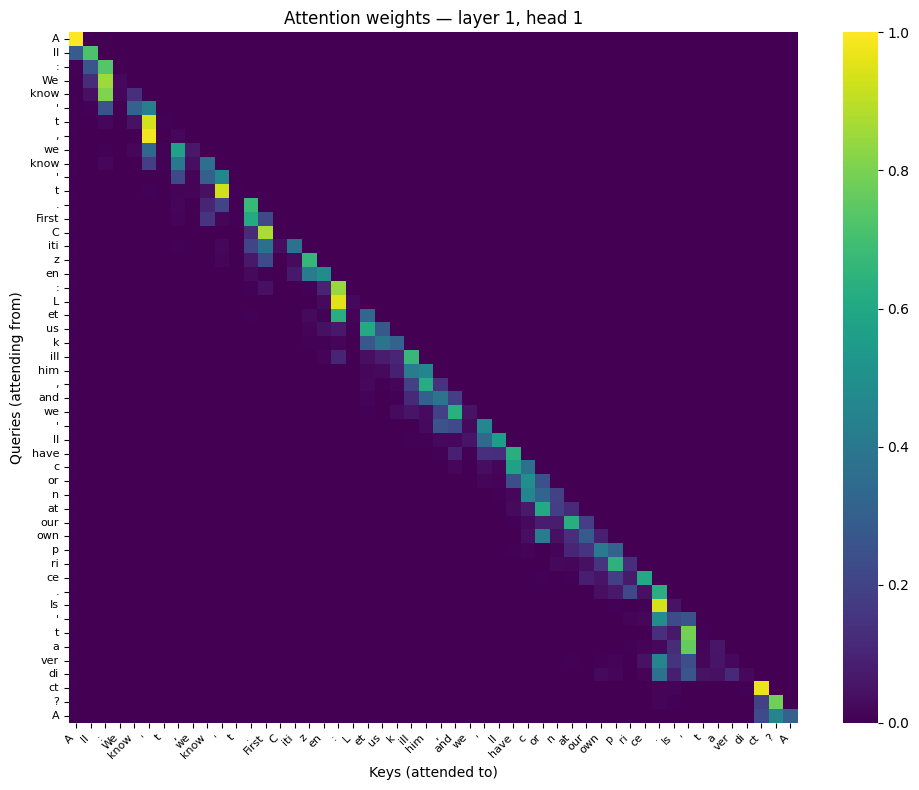

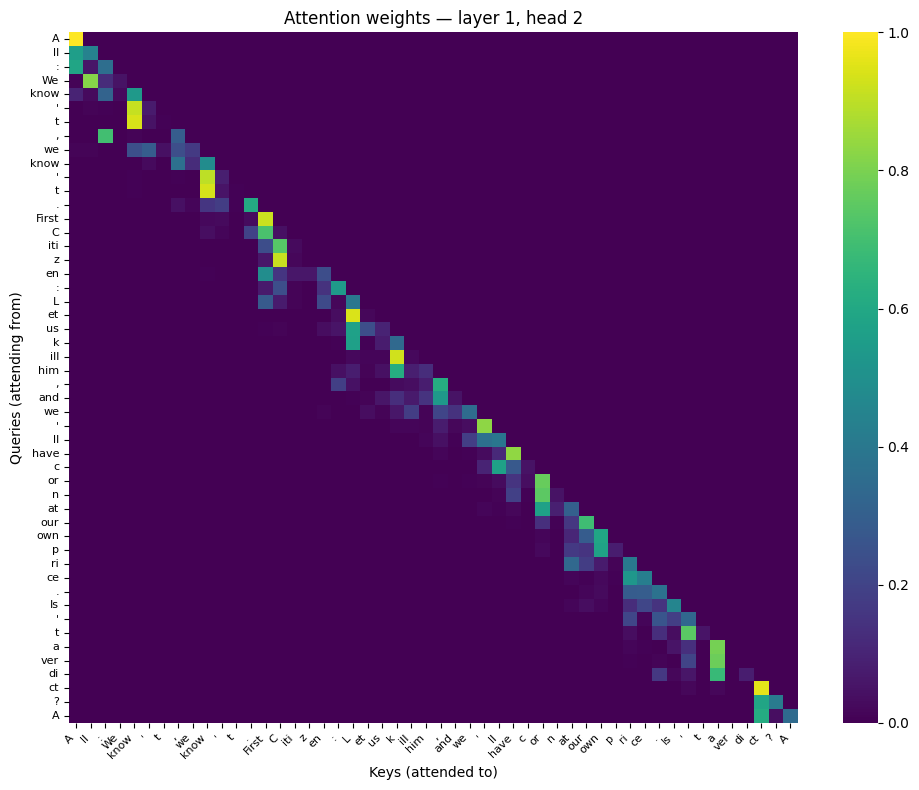

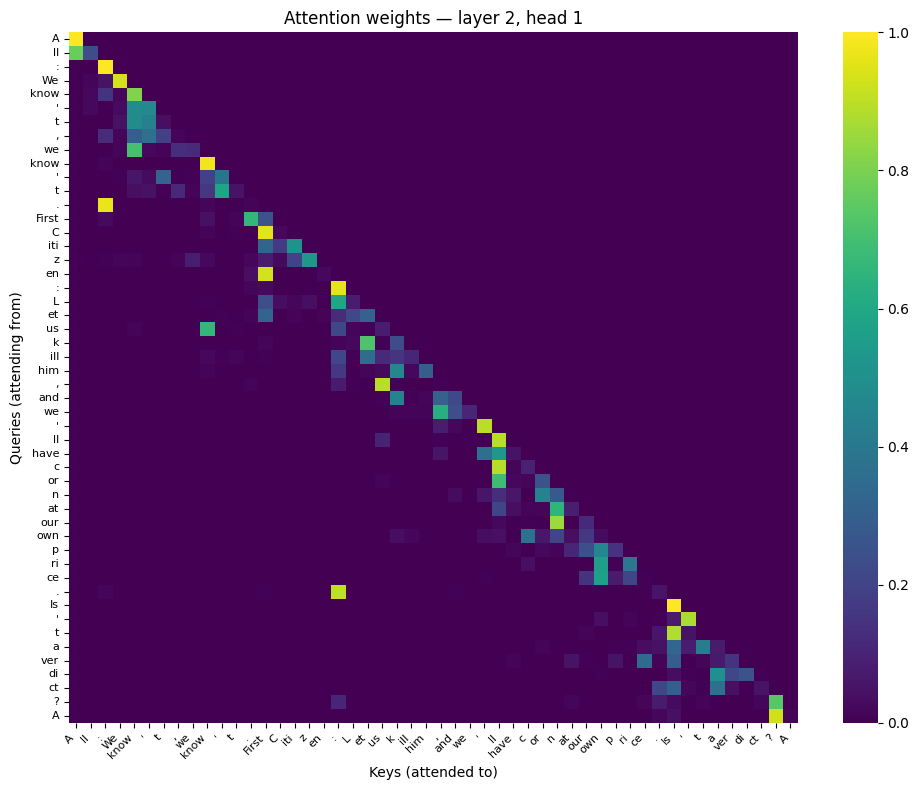

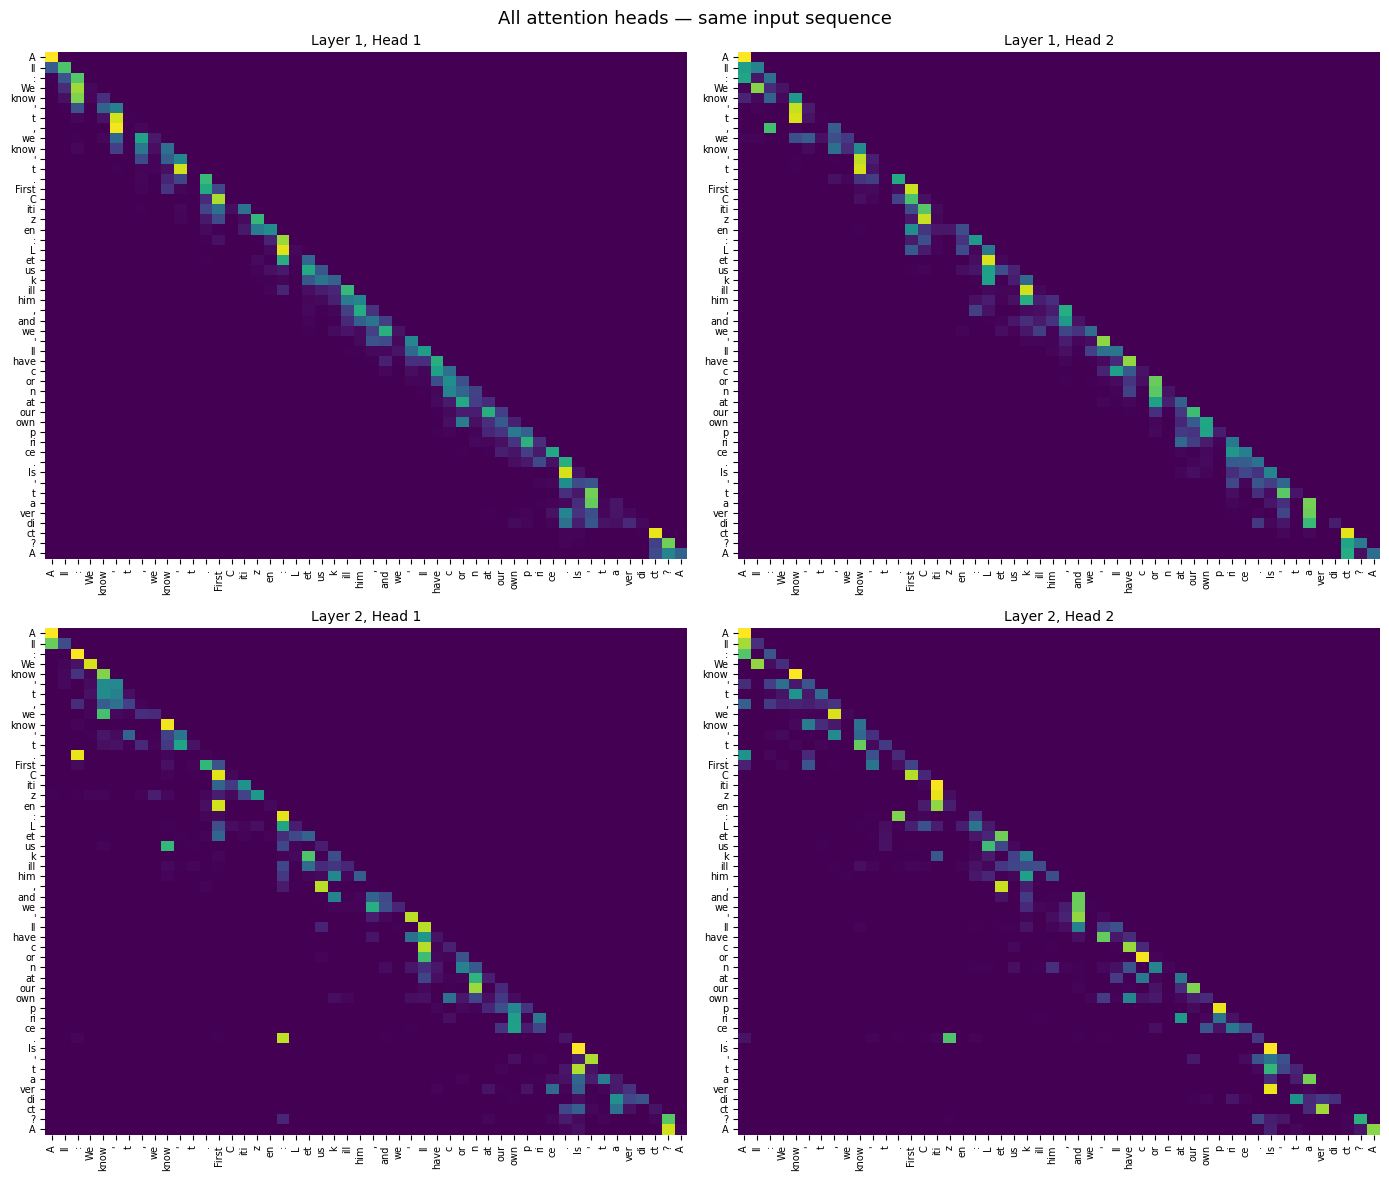

In [30]:
sample_ids = train_dataset[100][0]
token_strs = [tokenizer.id_to_token(i.item()) for i in sample_ids]
sample_text = tokenizer.decode(sample_ids.tolist())
print("Sample text:", sample_text)

def plot_attention(token_ids, token_strs, layer=0, head=0):
    x = torch.tensor(token_ids).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        _, all_weights = model(x)

    attn = all_weights[layer][0, head].cpu().numpy()

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn, xticklabels=token_strs, yticklabels=token_strs,
                cmap="viridis", vmin=0, vmax=attn.max())
    plt.title(f"Attention weights — layer {layer+1}, head {head+1}")
    plt.xlabel("Keys (attended to)")
    plt.ylabel("Queries (attending from)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"attn_layer{layer+1}_head{head+1}.png", dpi=150, bbox_inches='tight')
    plt.show()

token_ids_list = sample_ids.tolist()

plot_attention(token_ids_list, token_strs, layer=0, head=0)
plot_attention(token_ids_list, token_strs, layer=0, head=1)
plot_attention(token_ids_list, token_strs, layer=1, head=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
x = torch.tensor(token_ids_list).unsqueeze(0).to(device)
with torch.no_grad():
    _, all_weights = model(x)

for i, ax in enumerate(axes.flat):
    layer = i // 2
    head  = i % 2
    attn  = all_weights[layer][0, head].cpu().numpy()
    sns.heatmap(attn, ax=ax, xticklabels=token_strs, yticklabels=token_strs,
                cmap="viridis", cbar=False)
    ax.set_title(f"Layer {layer+1}, Head {head+1}", fontsize=10)
    ax.tick_params(labelsize=7)

plt.suptitle("All attention heads — same input sequence", fontsize=13)
plt.tight_layout()
plt.savefig("attn_multihead.png", dpi=150, bbox_inches='tight')
plt.show()